In [11]:
# CELL 1 — Setup (jalankan di awal setiap sesi baru)
# ============================================================

!pip install earthengine-api geemap rasterio matplotlib numpy --quiet

import ee
import geemap
import rasterio                    # membaca dan mengolah file GeoTIFF
import rasterio.plot as riplot     # visualisasi raster
import numpy as np                 # operasi array numerik
import matplotlib.pyplot as plt    # membuat grafik dan peta
import matplotlib.gridspec as gridspec  # layout multi-panel
from matplotlib.colors import Normalize
import os

# Autentikasi GEE
try:
    ee.Initialize(project="latihan-pemograman-spasial")  # ganti project ID Anda
    print("✅ GEE terhubung")
except:
    ee.Authenticate()
    ee.Initialize(project="latihan-pemograman-spasial")

# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Path ke folder proyek di Drive
DRIVE_BASE = "/content/drive/MyDrive/Colab Notebooks/ProyekGEE_PemSpasial"
PATH_T1    = f"{DRIVE_BASE}/data_processed/composite_T1.tif"
PATH_T2    = f"{DRIVE_BASE}/data_processed/composite_T2.tif"

# Cek apakah file sudah tersedia
for path, nama in [(PATH_T1,"T1"),(PATH_T2,"T2")]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f"✅ {nama}: {path} ({size_mb:.1f} MB)")
    else:
        print(f"❌ {nama}: FILE BELUM ADA — cek tab Tasks di GEE!")


✅ GEE terhubung
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ T1: /content/drive/MyDrive/Colab Notebooks/ProyekGEE_PemSpasial/data_processed/composite_T1.tif (13.6 MB)
✅ T2: /content/drive/MyDrive/Colab Notebooks/ProyekGEE_PemSpasial/data_processed/composite_T2.tif (13.6 MB)


In [12]:
# CELL 2 — Buka File GeoTIFF dan Lihat Informasinya
# ============================================================

# Buka file composite T2 menggunakan rasterio
with rasterio.open(PATH_T2) as src:
    # Baca semua informasi file
    print("=" * 55)
    print("INFORMASI FILE COMPOSITE T2")
    print("=" * 55)
    print(f"Jumlah band     : {src.count}")
    print(f"Lebar (piksel)  : {src.width}")
    print(f"Tinggi (piksel) : {src.height}")
    print(f"Proyeksi (CRS)  : {src.crs}")
    print(f"Resolusi        : {src.res[0]:.6f}° (~{src.res[0]*111000:.0f}m per piksel)")
    print(f"Bounding box    : {src.bounds}")
    print(f"Tipe data piksel: {src.dtypes[0]}")
    print()

    # Baca semua band ke dalam numpy array
    # Bentuk array: (n_bands, height, width)
    data_T2 = src.read()   # shape: (7, H, W) — 6 band SR + 1 band NDVI
    transform_T2 = src.transform  # informasi georeferensi
    crs_T2 = src.crs

# Pisahkan band-band penting
# Band urutan: SR_B2(idx0), SR_B3(idx1), SR_B4(idx2), SR_B5(idx3),
#             SR_B6(idx4), SR_B7(idx5), NDVI(idx6)
band_blue  = data_T2[1] # SR_B2 — Biru
band_green = data_T2[2]  # SR_B3 — Hijau
band_red   = data_T2[3]  # SR_B4 — Merah
band_nir   = data_T2[4]  # SR_B5 — Near Infrared
band_swir1 = data_T2[5]  # SR_B6 — Short Wave Infrared 1
band_ndvi  = data_T2[7]  # NDVI yang sudah dihitung di GEE

# Tampilkan statistik dasar setiap band
nama_band = ["B2-Biru","B3-Hijau","B4-Merah","B5-NIR","B6-SWIR1","B7-SWIR2","NDVI"]
print("\n=== Statistik Band Composite T2 ===")
for i, nama in enumerate(nama_band):
    band = data_T2[i]
    # Abaikan piksel no-data (biasanya nilai 0 atau negatif sangat ekstrem)
    valid = band[band > -9998]
    if len(valid) > 0:
        print(f"  {nama:12s}: min={valid.min():.4f}  max={valid.max():.4f}  mean={valid.mean():.4f}")


INFORMASI FILE COMPOSITE T2
Jumlah band     : 8
Lebar (piksel)  : 954
Tinggi (piksel) : 598
Proyeksi (CRS)  : EPSG:4326
Resolusi        : 0.000269° (~30m per piksel)
Bounding box    : BoundingBox(left=112.58998680900659, bottom=-7.351542790648929, right=112.8470846433216, top=-7.190385028677887)
Tipe data piksel: float32


=== Statistik Band Composite T2 ===
  B2-Biru     : min=0.0020  max=0.3231  mean=0.0678
  B3-Hijau    : min=0.0090  max=0.3848  mean=0.0771
  B4-Merah    : min=0.0307  max=0.4742  mean=0.1029
  B5-NIR      : min=0.0211  max=0.5707  mean=0.1064
  B6-SWIR1    : min=0.0128  max=0.7115  mean=0.2096
  B7-SWIR2    : min=0.0064  max=1.0456  mean=0.1861
  NDVI        : min=0.0045  max=1.0340  mean=0.1401


In [13]:
# CELL 3 — Fungsi Normalisasi untuk Visualisasi
# ============================================================

# Fungsi normalisasi: ubah nilai band ke rentang 0–1 untuk ditampilkan
# Tanpa ini, gambar akan terlalu gelap atau terlalu terang
def normalisasi_band(band, persen_rendah=2, persen_tinggi=98):
    """
    Normalisasi band citra ke rentang [0, 1]
    menggunakan percentile clipping untuk menghindari pengaruh outlier.

    persen_rendah=2  artinya 2% piksel terbawah di-set ke 0 (hitam)
    persen_tinggi=98 artinya 2% piksel teratas di-set ke 1 (putih)
    """
    # Ambil hanya piksel valid
    valid = band[band > -9998]
    if len(valid) == 0:
        return np.zeros_like(band, dtype=float)

    # Hitung batas bawah dan atas menggunakan percentile
    p_low  = np.percentile(valid, persen_rendah)
    p_high = np.percentile(valid, persen_tinggi)

    # Clip dan normalisasi: (nilai - min) / (max - min)
    normed = np.clip(band, p_low, p_high)
    normed = (normed - p_low) / (p_high - p_low)

    # Kembalikan dengan no-data tetap transparan (nan)
    normed[band <= -9998] = np.nan
    return normed


# Siapkan composite RGB untuk visualisasi True Color dan False Color
# True Color: Red=B4, Green=B3, Blue=B2
rgb_T2 = np.dstack([
    normalisasi_band(band_red),
    normalisasi_band(band_green),
    normalisasi_band(band_blue)
])  # bentuk: (H, W, 3)

# False Color: Red=B5(NIR), Green=B4, Blue=B3
# Vegetasi sehat tampak MERAH CERAH dalam composite ini
fcc_T2 = np.dstack([
    normalisasi_band(band_nir),
    normalisasi_band(band_red),
    normalisasi_band(band_green)
])

print("✅ Array RGB siap untuk visualisasi")
print(f"Bentuk array RGB: {rgb_T2.shape}  → (tinggi, lebar, 3 channel)")


✅ Array RGB siap untuk visualisasi
Bentuk array RGB: (598, 954, 3)  → (tinggi, lebar, 3 channel)


In [16]:
# CELL 4 — Visualisasi Quicklook T1 vs T2 (4 Panel)
# ============================================================

# Buka T1 juga untuk perbandingan
with rasterio.open(PATH_T1) as src:
    data_T1 = src.read()

band_red_T1  = data_T1[3]
band_green_T1 = data_T1[2]
band_blue_T1  = data_T1[1]
band_nir_T1   = data_T1[4]
band_ndvi_T1  = data_T1[7]

rgb_T1 = np.dstack([normalisasi_band(band_red_T1),
                    normalisasi_band(band_green_T1),
                    normalisasi_band(band_blue_T1)])

fcc_T1 = np.dstack([normalisasi_band(band_nir_T1),
                    normalisasi_band(band_red_T1),
                    normalisasi_band(band_green_T1)])

# Buat figure 4-panel: T1 True Color | T2 True Color
#                      T1 False Color | T2 False Color
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Quicklook Preprocessing: Perbandingan T1 vs T2\n" +
             "AOI: Kota Surabaya",  # ⚠ Ganti nama AOI
             fontsize=13, fontweight="bold", y=1.01)

# Panel kiri atas: T1 True Color
axes[0,0].imshow(rgb_T1)
axes[0,0].set_title(f"T1 — True Color\n(Warna Asli, periode tahun 2015-2018)",  # ⚠ Ganti
                   fontsize=10, fontweight="bold")
axes[0,0].axis("off")

# Panel kanan atas: T2 True Color
axes[0,1].imshow(rgb_T2)
axes[0,1].set_title(f"T2 — True Color\n(Warna Asli, periode tahun 2022-2025)",
                   fontsize=10, fontweight="bold")
axes[0,1].axis("off")

# Panel kiri bawah: T1 False Color
axes[1,0].imshow(fcc_T1)
axes[1,0].set_title("T1 — False Color NIR\n(Merah = Vegetasi Sehat)",
                   fontsize=10)
axes[1,0].axis("off")

# Panel kanan bawah: T2 False Color
axes[1,1].imshow(fcc_T2)
axes[1,1].set_title("T2 — False Color NIR\n(Merah = Vegetasi Sehat)",
                   fontsize=10)
axes[1,1].axis("off")

plt.tight_layout()

# Simpan quicklook ke Drive
path_quicklook = f"{DRIVE_BASE}/outputs/maps/quicklook_T1vsT2.png"
os.makedirs(os.path.dirname(path_quicklook), exist_ok=True)
plt.savefig(path_quicklook, dpi=150, bbox_inches="tight")
print(f"✅ Quicklook disimpan: {path_quicklook}")
plt.show()


Output hidden; open in https://colab.research.google.com to view.


📊 Rata-rata NDVI T1: 0.3147
📊 Rata-rata NDVI T2: 0.3173
📊 Perubahan NDVI (delta): +0.0026
➡ NDVI relatif stabil — perubahan minimal dalam periode ini


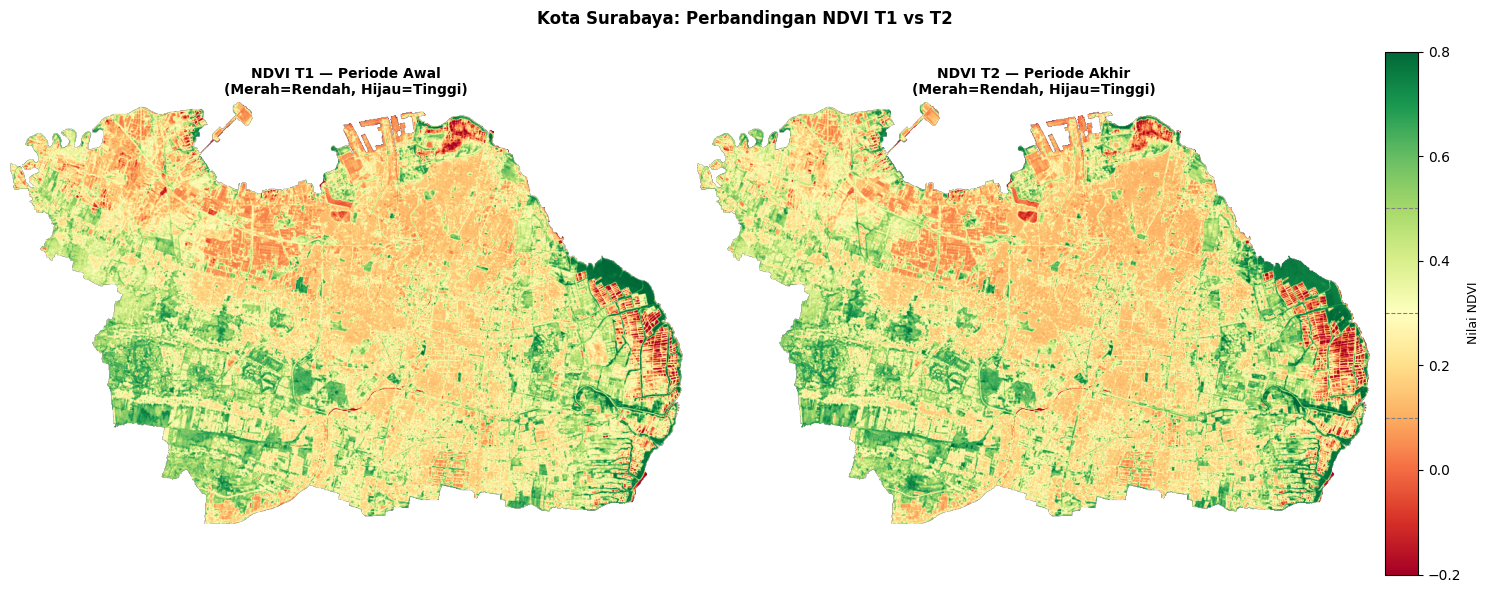

In [17]:
# CELL 5 — Visualisasi Peta NDVI dengan Colorbar Profesional
# ============================================================

# Buat figure untuk perbandingan NDVI T1 vs T2
fig, (ax1, ax2, cax) = plt.subplots(1, 3,
    figsize=(15, 6),
    gridspec_kw={"width_ratios": [1, 1, 0.05]})

# Normalisasi NDVI: rentang -0.2 sampai 0.8
ndvi_norm = Normalize(vmin=-0.2, vmax=0.8)
cmap_ndvi = plt.cm.RdYlGn  # merah-kuning-hijau, cocok untuk NDVI

# NDVI T1
ndvi_T1_masked = np.ma.masked_where(band_ndvi_T1 <= -9998, band_ndvi_T1)
im1 = ax1.imshow(ndvi_T1_masked, cmap=cmap_ndvi, norm=ndvi_norm)
ax1.set_title("NDVI T1 — Periode Awal\n(Merah=Rendah, Hijau=Tinggi)",
             fontsize=10, fontweight="bold")
ax1.axis("off")

# NDVI T2
ndvi_T2_masked = np.ma.masked_where(band_ndvi <= -9998, band_ndvi)
im2 = ax2.imshow(ndvi_T2_masked, cmap=cmap_ndvi, norm=ndvi_norm)
ax2.set_title("NDVI T2 — Periode Akhir\n(Merah=Rendah, Hijau=Tinggi)",
             fontsize=10, fontweight="bold")
ax2.axis("off")

# Colorbar
plt.colorbar(im1, cax=cax)
cax.set_ylabel("Nilai NDVI", fontsize=9)

# Tambahkan label interpretasi di colorbar
cax.axhline(y=0.1, color="gray", linewidth=0.8, linestyle="--")
cax.axhline(y=0.3, color="gray", linewidth=0.8, linestyle="--")
cax.axhline(y=0.5, color="gray", linewidth=0.8, linestyle="--")

fig.suptitle("Kota Surabaya: Perbandingan NDVI T1 vs T2",
             fontsize=12, fontweight="bold")
plt.tight_layout()

# Hitung rata-rata NDVI untuk anotasi
mean_ndvi_T1 = band_ndvi_T1[band_ndvi_T1 > -9998].mean()
mean_ndvi_T2 = band_ndvi[band_ndvi > -9998].mean()
delta_ndvi   = mean_ndvi_T2 - mean_ndvi_T1

print(f"\n📊 Rata-rata NDVI T1: {mean_ndvi_T1:.4f}")
print(f"📊 Rata-rata NDVI T2: {mean_ndvi_T2:.4f}")
print(f"📊 Perubahan NDVI (delta): {delta_ndvi:+.4f}")
if delta_ndvi < -0.05:
    print("⬇ NDVI menurun — kemungkinan degradasi vegetasi atau perluasan lahan terbuka")
elif delta_ndvi > 0.05:
    print("⬆ NDVI meningkat — kemungkinan peningkatan vegetasi atau revegetasi")
else:
    print("➡ NDVI relatif stabil — perubahan minimal dalam periode ini")

plt.savefig(f"{DRIVE_BASE}/outputs/maps/ndvi_T1vsT2.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# Salin ke TEXT/Markdown cell di Colab — bukan code cell!
# ============================================================

---
## 📔 Jurnal Harian — Pertemuan 3: Preprocessing
**Tanggal**: ___  |  **Nama**: ___  |  **AOI**: Kota Surabaya

### 🛰 Konfigurasi Preprocessing
| Parameter | Nilai | Alasan |
|-----------|-------|--------|
| Sensor T1 | Landsat 8 | Tersedia sejak 2013, cocok untuk merekam kondisi periode "sebelum" |
| Sensor T2 | Landsat 9 | Sensor terbaru, dipakai untuk periode "sesudah" agar data lebih baru |
| Periode T1 | 2015-01-01 sampai 2018-12-31 | Rentang cukup panjang untuk mendapatkan cukup scene bebas awan |
| Periode T2 | 2022-01-01 sampai 2025-12-31 | Periode terbaru untuk deteksi perubahan; dimulai 2022 karena Landsat 9 baru beroperasi penuh sejak akhir 2021 |
| Cloud threshold T1 | 80% | Dilonggarkan karena wilayah sering berawan dan jumlah scene sempat kurang di threshold ketat |
| Cloud threshold T2 | 70% | Dilonggarkan dengan alasan sama, meski data T2 relatif lebih banyak tersedia |
| Metode composite | median | Lebih tahan terhadap outlier/awan residu dibanding mean, dan tidak butuh band kualitas tambahan seperti qualityMosaic |

### 📊 Hasil Evaluasi Kualitas Composite
| Metrik | T1 | T2 | Status |
|--------|-----|-----|--------|
| Coverage (%) | 100% | 100% | ✅ Kedua composite memiliki data penuh di seluruh AOI, tanpa lubang akibat awan |
| Jumlah scene | 73 | 67 | ✅ Jumlah cukup memadai untuk kedua periode |
| NDVI mean | 0.3144 | 0.3221 | ✅ Nilai wajar untuk area perkotaan/campuran vegetasi (0–0.4 umum untuk Surabaya) |
| Reflektansi mean (B4) | 0.0715 | 0.0715 | ✅ Nilai sudah dalam rentang fisik wajar (0–1), hampir identik antar periode |

**Catatan tambahan hasil perbandingan resolusi (Script 6.1):**
| Metrik | Nilai |
|--------|-------|
| Jumlah piksel Landsat 9 (30m) | 2.229.835 |
| Jumlah piksel Sentinel-2 (10m) | 20.069.528 |
| Rasio resolusi (S2/L9) | 9× |

### 👁 Pengamatan Visual dari Quicklook
(Apa yang terlihat berbeda antara T1 dan T2?
 Area mana yang paling jelas menunjukkan perubahan?)

___

### ✅ Yang berhasil dikerjakan
- Membuat fungsi cloud masking Landsat 8/9 (`maskL89sr`) berbasis bit QA_PIXEL (Cloud & Cloud Shadow), dengan konversi skala reflektansi resmi Collection 2
- Membuat fungsi cloud masking Sentinel-2 (`maskS2scl`) berbasis band SCL
- Membangun pipeline composite T1 (73 citra) dan T2 (67 citra) dengan `buatComposite()`
- Menambahkan band NDVI ke masing-masing composite lewat `tambahNDVI()`
- Melakukan visualisasi True Color, False Color, dan NDVI untuk T1 & T2
- Berhasil membuat 2 task ekspor ke Google Drive (composite T1 dan T2, format Float, CRS EPSG:4326)
- Menghitung coverage T1 dan T2 — keduanya mencapai 100%, tidak ada lubang data akibat awan
- Menghitung statistik lengkap (mean, stdDev, min, max) band SR_B4, SR_B5, dan NDVI untuk T1 dan T2
- Menghitung delta NDVI antar periode sebagai indikator awal perubahan vegetasi
- Membandingkan resolusi spasial Landsat 9 (30m) vs Sentinel-2 (10m), dengan rasio piksel 9× sesuai teori

### ❌ Error yang ditemui dan solusinya
| Error | Penyebab | Solusi |
|-------|----------|--------|
| Citra tampil putih polos (piksel `masked`) | Semua scene dalam koleksi tertutup awan/bayangan tepat di titik yang sama, atau AOI menyentuh celah antar scene | Menaikkan `cloud_max_t1` ke 80% dan `cloud_max_t2` ke 70% — terbukti berhasil, coverage T1 & T2 akhirnya mencapai 100% |
| Nilai reflektansi tidak masuk akal (>1.0), menyebabkan citra tampil putih saat divisualisasikan | Salah rumus skala — memakai `.divide(10000)` (rumus Collection 1) padahal dataset yang dipakai adalah Collection 2 | Mengganti dengan rumus resmi Collection 2 untuk band optik: `select('SR_B.').multiply(0.0000275).add(-0.2)` |
| `Exported bands must have compatible data types: Float64 and Float32` | Band-band dalam citra hasil pemrosesan memiliki tipe data campuran | Menambahkan `.toFloat()` pada citra sebelum `Export.image.toDrive()` |
| Hasil export ke Drive membentuk folder aneh dengan tanda `/` di namanya | Parameter `folder` tidak mendukung path bertingkat | Menggunakan satu nama folder tunggal (`'data_processed'`) |
| `Image.reduceRegion: Too many pixels in the region` | Perhitungan `reduceRegion` pada resolusi terlalu halus (terutama scale 10m untuk Sentinel-2, ~20 juta piksel) melebihi batas default 10 juta | Menambahkan `maxPixels: 1e13` pada seluruh pemanggilan `reduceRegion` |
| `CONFIG.aoi` berpotensi invalid geometry | Struktur array pada `ee.Geometry.Polygon` kurang satu level nesting | Menambahkan kurung siku pembungkus ekstra untuk ring, atau memakai `ee.Geometry.Rectangle` |
| Statistik T2 dan coverage T2 belum pernah dihitung/di-print | Script evaluasi awal hanya mencakup T1 | Menambahkan blok kode `pixelCount_T2`, `coverageT2`, dan `statsT2` yang identik strukturnya dengan T1 |

### 💡 Keputusan teknis yang diambil
- **Sensor dipilih**: Landsat 8 untuk T1 dan Landsat 9 untuk T2, karena keduanya kompatibel band dan resolusi, serta mencakup rentang waktu yang dibutuhkan untuk analisis perubahan
- **Metode masking**: bit QA_PIXEL (Cloud & Cloud Shadow) untuk Landsat, band SCL untuk Sentinel-2, karena keduanya menyediakan klasifikasi piksel yang cukup detail
- **Metode compositing**: median, karena lebih robust terhadap sisa awan/outlier dibanding mean — terbukti mencapai coverage 100% pada T1 dan T2 setelah threshold cloud cover dilonggarkan

### 🔭 Temuan awal dari NDVI
- NDVI mean T1 = 0.3144, T2 = 0.3221, delta = +0.0077
- Interpretasi: NDVI T1 dan T2 hampir sama, cuma naik sedikit (+0.0077). Ini artinya secara rata-rata, kondisi vegetasi di Surabaya tidak banyak berubah antara periode 2015–2018 dan 2022–2025. Kenaikannya terlalu kecil untuk disebut tren nyata, jadi kemungkinan besar wilayah ini memang relatif stabil, atau perubahannya cuma terjadi di beberapa titik kecil saja yang tidak terlihat kalau cuma dilihat dari rata-rata satu angka untuk seluruh kota.

### ⭐ Hal paling menarik dari pertemuan ini
Ternyata NDVI lebih peka menangkap perubahan vegetasi dibanding cuma lihat dari satu band. Selain itu, ternyata resolusi Sentinel-2 yang 3x lebih detail dari Landsat bikin jumlah pikselnya 9x lebih banyak, jadi resolusi yang "kelihatannya" cuma 3x lebih tajam, ternyata datanya jauh lebih besar dari itu.

---